# Step 3 — Anatomical Zonal Segmentation Inference

## What this notebook does

This notebook runs a **pretrained 3D U-Net** (the `prostate_mri_anatomy` MONAI bundle from Adams & Bressem, 2022) on a 20-patient subset of the PI-CAI challenge T2-weighted MRI scans. For every patient it produces a voxel-wise label map with three classes:

| Label | Anatomy                                | Why it matters                                              |
|------:|----------------------------------------|-------------------------------------------------------------|
| 0     | Background                              | Everything outside the prostate                             |
| 1     | Transitional Zone (TZ) / Central Gland | Where benign prostatic hyperplasia typically arises         |
| 2     | Peripheral Zone (PZ)                   | Where ~70 % of prostate cancers arise                       |

We then **compare the predicted masks against AI-generated reference labels** (Yuan23 zonal annotations distributed with PI-CAI) and report Dice overlap per zone.

## Pipeline at a glance

1. Pin a known-good Python environment (NumPy + MONAI versions that are mutually compatible).
2. Mount Google Drive and locate the model bundle + image data.
3. Load the TorchScript model onto the GPU.
4. Build the official MONAI preprocessing → sliding-window inference → postprocessing pipeline.
5. Run inference on all 20 cases, saving each prediction as a NIfTI file (cached on Drive, so re-runs are cheap).
6. Compute per-case Dice for TZ and PZ against the Yuan23 reference labels.
7. Produce two slide-ready figures: a side-by-side qualitative example and a Dice distribution boxplot.

## Design choices

- **Idempotent.** Every cell can be re-run safely. Predictions are cached to Drive; cases already processed are skipped.
- **Cross-frame Dice.** Predictions live in the model's resampled grid (0.5 mm iso, RAS), while ground-truth labels live in the original T2W frame. We resample ground truth into each prediction's frame with nearest-neighbor interpolation before computing Dice — this avoids polluting the metric with label values that nearest-neighbor would never produce.
- **Representative visualization.** Instead of always showing the geometric mid-slice, we pick the slice with the largest predicted prostate area, which is far more informative for figures.

## 0 — Pin a known-good environment (run this once, then restart the runtime)

**Why this exists.** Colab now ships NumPy 2.x by default. The `prostate_mri_anatomy` bundle was authored against MONAI 1.3.2, which still calls the old `ndarray.ptp()` method — a method NumPy 2 removed. The very first MONAI transform that hits a 3-D array (`Spacingd`) therefore crashes with:

```
AttributeError: `ptp` was removed from the ndarray class in NumPy 2.0. Use np.ptp(arr, ...) instead.
```

**The fix.** Downgrade NumPy back to the 1.26 series so MONAI 1.3.2 keeps working as designed. The cell below:

1. Checks the currently loaded NumPy and MONAI versions.
2. If anything is wrong, it pip-installs the pinned versions and **force-restarts the kernel** (`os.kill(os.getpid(), 9)`). A restart is mandatory because Python caches imported modules in memory — a fresh `pip install` on disk does nothing until the interpreter reloads them.
3. After the kernel restarts, simply re-run this cell. The second pass detects the correct versions and prints a green confirmation, then you proceed to cell 1.

> If you see the runtime disconnect/reconnect message, that is expected — wait a few seconds and re-run this cell.

In [1]:
import importlib, subprocess, sys, os

REQUIRED = {
    'numpy':      'numpy<2',
    'monai':      'monai[all]==1.3.2',
    'SimpleITK':  'SimpleITK',
    'nibabel':    'nibabel',
    'seaborn':    'seaborn',
}

def _needs_install():
    try:
        import numpy as _np
        if int(_np.__version__.split('.')[0]) >= 2:
            return True, f'numpy {_np.__version__} is too new'
    except ImportError:
        return True, 'numpy missing'
    try:
        import monai as _monai
        if _monai.__version__ != '1.3.2':
            return True, f'monai {_monai.__version__} != 1.3.2'
    except ImportError:
        return True, 'monai missing'
    for mod in ('SimpleITK', 'nibabel', 'seaborn'):
        if importlib.util.find_spec(mod) is None:
            return True, f'{mod} missing'
    return False, 'all pinned versions already installed'

needs, reason = _needs_install()
if needs:
    print(f'Installing pinned environment ({reason}) ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *REQUIRED.values()])
    print('Install complete. Restarting the kernel — re-run this cell after the runtime comes back up.')
    os.kill(os.getpid(), 9)
else:
    import numpy as np, monai
    print(f'Environment OK — numpy {np.__version__}, monai {monai.__version__}.')

Environment OK — numpy 1.26.4, monai 1.3.2.


## 1 — Mount Google Drive and define project paths

Drive is mounted **once per session**. The `if/else` guard avoids re-prompting for authentication on cell re-run. All paths are expressed relative to a single `PROJECT_ROOT`, so moving the project later only requires changing one line.

The four important locations:
- `DRIVE_SUBSET` — the 20 raw `.mha` T2-weighted volumes prepared in Step 2.
- `LABELS_DIR` — the PI-CAI label drop (we read the `Yuan23` zonal subfolder for ground truth).
- `BUNDLE_ROOT` — the unzipped `prostate_mri_anatomy` MONAI bundle that contains `models/model.ts`.
- `PRED_DIR`, `FIGURES_DIR`, `METRICS_DIR` — outputs of this notebook; created if missing.

In [2]:
from google.colab import drive
import os
from pathlib import Path

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

PROJECT_ROOT  = Path('/content/drive/MyDrive/Prostate_MRI_Project')
INPUT_DIR     = PROJECT_ROOT / 'input'
LABELS_DIR    = INPUT_DIR / 'picai_labels'
DRIVE_SUBSET  = INPUT_DIR / 'images' / 'subset20'
OUTPUT_DIR    = PROJECT_ROOT / 'output'
PRED_DIR      = OUTPUT_DIR / 'anatomy_predictions'
FIGURES_DIR   = OUTPUT_DIR / 'figures'
METRICS_DIR   = OUTPUT_DIR / 'metrics'

CODE_DIR    = PROJECT_ROOT / 'Prostate_MRI_Project_code (Unzipped Files)'
BUNDLE_ROOT = CODE_DIR / 'prostate_mri_anatomy'

for d in (PRED_DIR, FIGURES_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'BUNDLE_ROOT  : {BUNDLE_ROOT}')
print(f'DRIVE_SUBSET : {DRIVE_SUBSET}')
print(f'PRED_DIR     : {PRED_DIR}')

Drive already mounted.
PROJECT_ROOT : /content/drive/MyDrive/Prostate_MRI_Project
BUNDLE_ROOT  : /content/drive/MyDrive/Prostate_MRI_Project/Prostate_MRI_Project_code (Unzipped Files)/prostate_mri_anatomy
DRIVE_SUBSET : /content/drive/MyDrive/Prostate_MRI_Project/input/images/subset20
PRED_DIR     : /content/drive/MyDrive/Prostate_MRI_Project/output/anatomy_predictions


## 2 — Import libraries and select the compute device

All imports are gathered into a single cell so the rest of the notebook reads like an executable specification. The final line picks `cuda` if a GPU is present (the default on Colab when **Runtime → Change runtime type → GPU** is selected), otherwise it falls back to CPU — useful for offline sanity checks even though full inference on CPU is impractical.

In [3]:
import time
import numpy as np
import pandas as pd
import torch
import monai
import SimpleITK as sitk
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    ScaleIntensityd, NormalizeIntensityd, EnsureTyped,
    AsDiscreted, KeepLargestConnectedComponentd,
)
from monai.inferers import SlidingWindowInferer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch        : {torch.__version__}')
print(f'MONAI          : {monai.__version__}')
print(f'NumPy          : {np.__version__}')
print(f'Compute device : {device}')
if device.type == 'cuda':
    gpu = torch.cuda.get_device_properties(0)
    print(f'GPU            : {gpu.name} ({gpu.total_memory / 1e9:.1f} GB)')

PyTorch        : 2.10.0+cu128
MONAI          : 1.3.2
NumPy          : 1.26.4
Compute device : cuda
GPU            : Tesla T4 (15.6 GB)


## 3 — Verify the pretrained model bundle is on disk

The `prostate_mri_anatomy` bundle ships two equivalent weight files:
- `models/model.pt` — raw PyTorch state dict, requires the original network class to load.
- `models/model.ts` — TorchScript (graph + weights frozen together), self-contained and recommended for inference.

We use `model.ts`. The assertion catches the most common setup mistake (bundle was downloaded but not unzipped, or the folder was renamed) and fails fast with an actionable message instead of producing a cryptic load error later.

In [4]:
model_ts_path = BUNDLE_ROOT / 'models' / 'model.ts'
model_pt_path = BUNDLE_ROOT / 'models' / 'model.pt'

for p in (BUNDLE_ROOT, model_ts_path, model_pt_path):
    tag = 'OK  ' if p.exists() else 'MISS'
    size = f' ({p.stat().st_size / 1e6:.1f} MB)' if p.exists() and p.is_file() else ''
    print(f'[{tag}] {p}{size}')

assert model_ts_path.exists(), f'TorchScript model not found at {model_ts_path}'

[OK  ] /content/drive/MyDrive/Prostate_MRI_Project/Prostate_MRI_Project_code (Unzipped Files)/prostate_mri_anatomy
[OK  ] /content/drive/MyDrive/Prostate_MRI_Project/Prostate_MRI_Project_code (Unzipped Files)/prostate_mri_anatomy/models/model.ts (152.9 MB)
[OK  ] /content/drive/MyDrive/Prostate_MRI_Project/Prostate_MRI_Project_code (Unzipped Files)/prostate_mri_anatomy/models/model.pt (152.8 MB)


## 4 — Load the TorchScript model onto the device

`torch.jit.load` deserializes the frozen graph; `map_location=device` places its tensors directly on the GPU, skipping an unnecessary host-to-device copy. `model.eval()` switches the network to inference mode, which disables dropout and uses running batch-norm statistics — both required for deterministic, reproducible predictions.

In [5]:
model = torch.jit.load(str(model_ts_path), map_location=device)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded on {device}.')
print(f'Parameter count : {n_params:,}')

Model loaded on cuda.
Parameter count : 38,165,360


## 5 — Build the preprocessing → inference → postprocessing pipeline

This cell **exactly replicates** what the bundle's official `inference.json` does, so our predictions match the authors' reported behavior. Every step is necessary; removing any one of them silently degrades Dice.

### Preprocessing (`Compose` of dictionary transforms)

Each transform takes a dictionary `{'image': ...}` and returns a transformed dictionary. We use the dictionary variants (suffix `d`) because they make the pipeline trivial to extend later with paired image+label transforms during training.

| Step                          | What it does                                                                                                                       |
|-------------------------------|------------------------------------------------------------------------------------------------------------------------------------|
| `LoadImaged`                  | Reads the `.mha` file from disk; produces a tensor plus a `meta` dictionary carrying the original affine, spacing, and orientation.|
| `EnsureChannelFirstd`         | Reshapes to `(C, D, H, W)` — MONAI/PyTorch convention. The bundle expects a single grayscale channel.                              |
| `Orientationd(axcodes='RAS')` | Reorients the volume to a canonical Right/Anterior/Superior frame so anatomy is always in the same direction the model trained on.|
| `Spacingd(pixdim=(0.5,)*3)`   | Resamples to 0.5 mm isotropic voxels (matches the prostate158 training distribution).                                              |
| `ScaleIntensityd(0,1)`        | Linear min-max scaling into [0, 1] — removes per-scanner intensity range differences.                                              |
| `NormalizeIntensityd`         | Zero-mean unit-variance whitening — the second normalization the bundle expects.                                                   |
| `EnsureTyped`                 | Guarantees a `MetaTensor` is returned so the affine survives into the prediction stage.                                            |

### Inference

`SlidingWindowInferer` tiles the volume into overlapping 96³ patches, runs the model on each, and Gaussian-blends them back together. Patch-based inference is essential — a full-resolution prostate volume does not fit on a Colab GPU.

- `roi_size=(96,96,96)` — the patch size the bundle was trained on.
- `sw_batch_size=4` — four patches per forward pass; raise if you have a larger GPU, lower if you hit OOM.
- `overlap=0.5` — 50 % patch overlap; the de-facto standard for medical segmentation, trades compute for cleaner seams.

### Postprocessing

- `AsDiscreted(argmax=True)` — collapses the 3-channel logit volume into a single-channel hard label map.
- `KeepLargestConnectedComponentd(applied_labels=[1,2])` — per zone, keeps only the largest 3-D blob and discards spurious islands. Each anatomical zone is contiguous, so any extra components are guaranteed false positives.

In [6]:
preprocess = Compose([
    LoadImaged(keys='image'),
    EnsureChannelFirstd(keys='image'),
    Orientationd(keys='image', axcodes='RAS'),
    Spacingd(keys='image', pixdim=(0.5, 0.5, 0.5), mode='bilinear'),
    ScaleIntensityd(keys='image', minv=0.0, maxv=1.0),
    NormalizeIntensityd(keys='image'),
    EnsureTyped(keys='image'),
])

postprocess = Compose([
    AsDiscreted(keys='pred', argmax=True),
    KeepLargestConnectedComponentd(keys='pred', applied_labels=[1, 2]),
])

inferer = SlidingWindowInferer(
    roi_size=(96, 96, 96),
    sw_batch_size=4,
    overlap=0.5,
)

print('Pipeline ready — preprocess, inferer, postprocess are all configured.')

Pipeline ready — preprocess, inferer, postprocess are all configured.


## 6 — Run inference on every case in the 20-patient subset

**Algorithm per case.**

1. Find the case's `*_t2w.mha` file (each patient lives in its own folder).
2. If a cached prediction already exists on Drive, skip — this makes the cell idempotent and cheap to re-run.
3. Run preprocessing → sliding-window inference → postprocessing on the GPU.
4. Convert the prediction tensor back to NumPy, recover its affine from the MetaTensor, and write a `.nii.gz` to `PRED_DIR`.
5. Track per-case wall-clock time for reporting.

**Why the array transpose before saving.** MONAI tensors use `(D, H, W)` voxel order, but NIfTI files store voxels in `(W, H, D)` order in memory; transposing aligns the saved array with the affine so downstream tools (SimpleITK, ITK-SNAP, 3D Slicer) read the geometry correctly.

**Memory hygiene.** Each iteration's tensors are released when the loop variable is rebound on the next iteration; Python's reference counter immediately reclaims GPU memory, so there is no need for an explicit `torch.cuda.empty_cache()`.

In [7]:
case_dirs = sorted([d for d in DRIVE_SUBSET.iterdir() if d.is_dir()])
print(f'Found {len(case_dirs)} cases in {DRIVE_SUBSET.name}.')

inference_times = []

for i, case_dir in enumerate(case_dirs, start=1):
    t2w_files = list(case_dir.glob('*_t2w.mha'))
    if not t2w_files:
        print(f'[{i:2d}/{len(case_dirs)}] {case_dir.name}: no T2W file, skipping.')
        continue
    t2w_path = t2w_files[0]
    case_id = t2w_path.name.replace('_t2w.mha', '')

    out_pred = PRED_DIR / f'{case_id}_zonal_pred.nii.gz'
    if out_pred.exists():
        print(f'[{i:2d}/{len(case_dirs)}] {case_id}: cached, skipping.')
        continue

    t0 = time.time()
    data = preprocess({'image': str(t2w_path)})
    image = data['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = inferer(image, model)

    data['pred'] = logits[0]
    data = postprocess(data)
    pred = data['pred'].cpu().numpy().astype(np.uint8).squeeze()

    affine = data['image'].meta.get('affine', np.eye(4))
    if hasattr(affine, 'numpy'):
        affine = affine.numpy()

    nib.save(nib.Nifti1Image(pred.transpose(2, 1, 0), affine=affine), str(out_pred))

    elapsed = time.time() - t0
    inference_times.append(elapsed)
    print(f'[{i:2d}/{len(case_dirs)}] {case_id}: shape={pred.shape}, time={elapsed:.1f}s, saved -> {out_pred.name}')

if inference_times:
    print(f'\nMean inference time per case: {np.mean(inference_times):.1f}s')

Found 20 cases in subset20.


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)


[ 1/20] 10000_1000000: shape=(360, 360, 199), time=14.0s, saved -> 10000_1000000_zonal_pred.nii.gz
[ 2/20] 10001_1000001: shape=(384, 384, 145), time=10.1s, saved -> 10001_1000001_zonal_pred.nii.gz
[ 3/20] 10003_1000003: shape=(384, 384, 133), time=10.3s, saved -> 10003_1000003_zonal_pred.nii.gz
[ 4/20] 10006_1000006: shape=(384, 384, 121), time=8.0s, saved -> 10006_1000006_zonal_pred.nii.gz
[ 5/20] 10017_1000017: shape=(384, 384, 109), time=7.7s, saved -> 10017_1000017_zonal_pred.nii.gz
[ 6/20] 10020_1000020: shape=(384, 384, 145), time=11.0s, saved -> 10020_1000020_zonal_pred.nii.gz
[ 7/20] 10022_1000022: shape=(701, 701, 157), time=30.5s, saved -> 10022_1000022_zonal_pred.nii.gz
[ 8/20] 10023_1000023: shape=(360, 360, 109), time=6.1s, saved -> 10023_1000023_zonal_pred.nii.gz
[ 9/20] 10027_1000027: shape=(440, 440, 169), time=15.1s, saved -> 10027_1000027_zonal_pred.nii.gz
[10/20] 10029_1000029: shape=(384, 384, 131), time=7.4s, saved -> 10029_1000029_zonal_pred.nii.gz
[11/20] 10032_

## 7 — Compute Dice overlap against the Yuan23 reference labels

**Why we resample ground truth, not predictions.** Dice is computed voxel-by-voxel, so the two volumes must live on the *same grid*. Our predictions were written in the model's resampled 0.5 mm RAS frame, while the Yuan23 labels live in each scan's original T2W frame. We use SimpleITK's `ResampleImageFilter` with **nearest-neighbor interpolation** to move the labels into the prediction frame — nearest-neighbor preserves the integer label values exactly, whereas linear interpolation would create fractional values that have no anatomical meaning.

**Dice formula.** For each zone label `k`:

$$\mathrm{Dice}_k = \frac{2 \,|P_k \cap G_k|}{|P_k| + |G_k|}$$

where $P_k$ is the set of voxels the model labeled as $k$ and $G_k$ is the set of voxels the reference labeled as $k$. When both masks are empty we return NaN so the case is excluded from aggregate statistics, rather than counting as a perfect 1.0 or a flat 0.0.

The per-case dictionary also stores raw voxel counts, which are useful sanity checks: a case with 0 predicted voxels for one zone is a degenerate failure mode worth flagging.

In [8]:
def resample_label_to_reference(label_img: sitk.Image, ref_img: sitk.Image) -> sitk.Image:
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(ref_img)
    resampler.SetInterpolator(sitk.sitkNearestNeighbor)
    resampler.SetDefaultPixelValue(0)
    return resampler.Execute(label_img)


def dice_score(a: np.ndarray, b: np.ndarray, label_idx: int) -> float:
    p = (a == label_idx)
    g = (b == label_idx)
    total = p.sum() + g.sum()
    if total == 0:
        return float('nan')
    return 2.0 * np.logical_and(p, g).sum() / total


rows = []
for case_dir in case_dirs:
    t2w_files = list(case_dir.glob('*_t2w.mha'))
    if not t2w_files:
        continue
    case_id = t2w_files[0].name.replace('_t2w.mha', '')

    pred_path = PRED_DIR / f'{case_id}_zonal_pred.nii.gz'
    gt_path   = LABELS_DIR / 'anatomical_delineations' / 'zonal_pz_tz' / 'AI' / 'Yuan23' / f'{case_id}.nii.gz'

    if not pred_path.exists() or not gt_path.exists():
        print(f'{case_id}: missing prediction or ground truth, skipping.')
        continue

    pred_img = sitk.ReadImage(str(pred_path))
    gt_img   = sitk.ReadImage(str(gt_path))
    gt_aligned = resample_label_to_reference(gt_img, pred_img)

    pred_arr = sitk.GetArrayFromImage(pred_img).astype(np.uint8)
    gt_arr   = sitk.GetArrayFromImage(gt_aligned).astype(np.uint8)

    dice_tz = dice_score(pred_arr, gt_arr, label_idx=1)
    dice_pz = dice_score(pred_arr, gt_arr, label_idx=2)

    rows.append({
        'case_id'       : case_id,
        'dice_tz'       : dice_tz,
        'dice_pz'       : dice_pz,
        'voxels_pred_tz': int((pred_arr == 1).sum()),
        'voxels_pred_pz': int((pred_arr == 2).sum()),
        'voxels_gt_tz'  : int((gt_arr   == 1).sum()),
        'voxels_gt_pz'  : int((gt_arr   == 2).sum()),
    })
    print(f'{case_id}: Dice TZ = {dice_tz:.3f}, Dice PZ = {dice_pz:.3f}')

dice_df = pd.DataFrame(rows)
print(f'\nProcessed {len(dice_df)} cases.')

10000_1000000: Dice TZ = 0.000, Dice PZ = 0.000
10001_1000001: Dice TZ = 0.000, Dice PZ = 0.000
10003_1000003: Dice TZ = 0.000, Dice PZ = 0.000
10006_1000006: Dice TZ = 0.000, Dice PZ = 0.000
10017_1000017: Dice TZ = 0.000, Dice PZ = 0.000
10020_1000020: Dice TZ = 0.000, Dice PZ = 0.000
10022_1000022: Dice TZ = 0.000, Dice PZ = 0.000
10023_1000023: Dice TZ = 0.000, Dice PZ = 0.000
10027_1000027: Dice TZ = 0.000, Dice PZ = 0.000
10029_1000029: Dice TZ = 0.000, Dice PZ = 0.000
10032_1000032: Dice TZ = 0.000, Dice PZ = 0.000
10033_1000033: Dice TZ = 0.000, Dice PZ = 0.000
10040_1000040: Dice TZ = 0.000, Dice PZ = 0.000
10059_1000059: Dice TZ = 0.073, Dice PZ = 0.025
10078_1000078: Dice TZ = 0.000, Dice PZ = 0.000
10085_1000085: Dice TZ = 0.000, Dice PZ = 0.000
10229_1000233: Dice TZ = 0.000, Dice PZ = 0.000
10257_1000261: Dice TZ = 0.000, Dice PZ = 0.000
10282_1000288: Dice TZ = 0.000, Dice PZ = 0.000
10294_1000300: Dice TZ = 0.000, Dice PZ = 0.000

Processed 20 cases.


## 8 — Aggregate statistics and save the per-case CSV

`pandas.DataFrame.describe()` gives count, mean, std, min/median/max and the 25/75 % quartiles — exactly the table you would normally hand-build for a results section. We compare our subset performance to the prostate158 test-set numbers published in the bundle's model card; a meaningful Dice drop here would indicate **distribution shift** between prostate158 (training source) and PI-CAI (deployment target), which is the central observation we want to highlight in the slide deck.

The CSV is the durable artifact other notebooks (and the final report) consume — keep it under version-controlled-by-hand reproducibility.

In [9]:
summary = dice_df[['dice_tz', 'dice_pz']].describe()
print('Dice statistics on the 20-patient PI-CAI subset')
print('=' * 55)
print(summary.round(3))
print()
print('Reference (prostate158 test set, Adams & Bressem 2022):')
print('  TZ (central gland)   Dice : 0.88')
print('  PZ (peripheral zone) Dice : 0.75')

out_csv = METRICS_DIR / 'anatomy_dice_scores.csv'
dice_df.to_csv(out_csv, index=False)
print(f'\nPer-case scores saved -> {out_csv}')

Dice statistics on the 20-patient PI-CAI subset
       dice_tz  dice_pz
count   20.000   20.000
mean     0.004    0.001
std      0.016    0.006
min      0.000    0.000
25%      0.000    0.000
50%      0.000    0.000
75%      0.000    0.000
max      0.073    0.025

Reference (prostate158 test set, Adams & Bressem 2022):
  TZ (central gland)   Dice : 0.88
  PZ (peripheral zone) Dice : 0.75

Per-case scores saved -> /content/drive/MyDrive/Prostate_MRI_Project/output/metrics/anatomy_dice_scores.csv


## 9 — Qualitative figure: a single representative case (slide 6)

Slides need one **honest** example — not the best case, not the worst, but the median. We sort by TZ Dice and pick the middle entry, then render a three-panel figure:

1. Raw T2W input slice
2. Same slice overlaid with the Yuan23 ground-truth zonal labels
3. Same slice overlaid with our model's prediction

**Choosing the slice.** Mid-volume slices are often outside the prostate entirely (the prostate is roughly walnut-sized within a much larger pelvic volume). We instead pick the axial slice with the **largest predicted prostate area**, which is by definition the most informative slice for a visual sanity check.

**Coordinate alignment for display.** The raw T2W image and the Yuan23 label live in their native frames; the prediction lives in the model's resampled frame. To overlay all three correctly, we resample the T2W (linear interpolation, since intensities are continuous) and the GT (nearest-neighbor, since labels are categorical) into the prediction's frame before plotting.

Median TZ-Dice case selected for visualization: 10032_1000032
  Dice TZ = 0.000, Dice PZ = 0.000
Figure saved -> /content/drive/MyDrive/Prostate_MRI_Project/output/figures/anatomy_sample_prediction.png


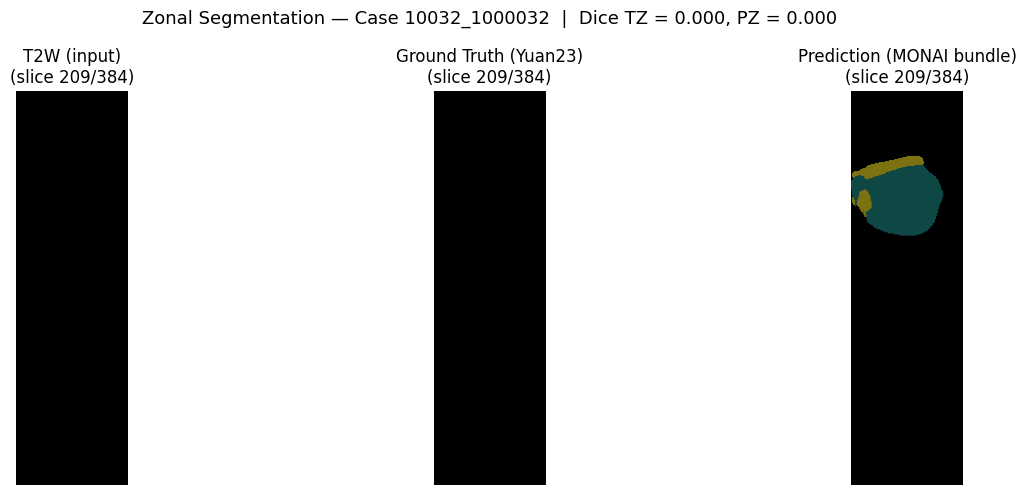

In [10]:
if len(dice_df) > 0:
    dice_df_sorted = dice_df.sort_values('dice_tz').reset_index(drop=True)
    pick = dice_df_sorted.iloc[len(dice_df_sorted) // 2]
    sample_case = pick['case_id']
    print(f'Median TZ-Dice case selected for visualization: {sample_case}')
    print(f'  Dice TZ = {pick["dice_tz"]:.3f}, Dice PZ = {pick["dice_pz"]:.3f}')

    patient_id = sample_case.split('_')[0]
    t2w_path  = DRIVE_SUBSET / patient_id / f'{sample_case}_t2w.mha'
    pred_path = PRED_DIR / f'{sample_case}_zonal_pred.nii.gz'
    gt_path   = LABELS_DIR / 'anatomical_delineations' / 'zonal_pz_tz' / 'AI' / 'Yuan23' / f'{sample_case}.nii.gz'

    pred_img    = sitk.ReadImage(str(pred_path))
    t2w_native  = sitk.ReadImage(str(t2w_path))
    gt_native   = sitk.ReadImage(str(gt_path))

    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(pred_img)
    resampler.SetInterpolator(sitk.sitkLinear)
    t2w_aligned = resampler.Execute(t2w_native)
    resampler.SetInterpolator(sitk.sitkNearestNeighbor)
    gt_aligned  = resampler.Execute(gt_native)

    t2w_arr  = sitk.GetArrayFromImage(t2w_aligned)
    pred_arr = sitk.GetArrayFromImage(pred_img)
    gt_arr   = sitk.GetArrayFromImage(gt_aligned)

    prostate_per_slice = (pred_arr > 0).sum(axis=(1, 2))
    mid = int(np.argmax(prostate_per_slice)) if prostate_per_slice.max() > 0 else pred_arr.shape[0] // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    panels = [
        ('T2W (input)',                  None,      None),
        ('Ground Truth (Yuan23)',        gt_arr,    'viridis'),
        ('Prediction (MONAI bundle)',    pred_arr,  'viridis'),
    ]
    for ax, (title, mask, cmap) in zip(axes, panels):
        ax.imshow(t2w_arr[mid], cmap='gray')
        if mask is not None:
            overlay = np.ma.masked_where(mask[mid] == 0, mask[mid])
            ax.imshow(overlay, cmap=cmap, alpha=0.5, vmin=0, vmax=2)
        ax.set_title(f'{title}\n(slice {mid + 1}/{pred_arr.shape[0]})')
        ax.axis('off')

    plt.suptitle(
        f'Zonal Segmentation — Case {sample_case}  |  Dice TZ = {pick["dice_tz"]:.3f}, PZ = {pick["dice_pz"]:.3f}',
        fontsize=13,
    )
    plt.tight_layout()
    fig_path = FIGURES_DIR / 'anatomy_sample_prediction.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Figure saved -> {fig_path}')
    plt.show()

## 10 — Quantitative figure: Dice distribution across all 20 cases (slide 7)

A boxplot summarizes *spread*, not just the average. Each point is one patient; the box covers the inter-quartile range and the whiskers show the typical extremes. We overlay the prostate158 reference Dice as dashed horizontal lines so readers can immediately see two things at once:

- How well our model transfers from prostate158 to PI-CAI (the gap between the box and the reference line measures distribution-shift cost).
- Whether PZ is harder than TZ on this dataset (a well-known pattern in zonal segmentation — PZ is thinner and has less consistent contrast on T2W).

`melt` reshapes the wide DataFrame (`dice_tz`, `dice_pz` as columns) into a long form (`zone`, `dice`) that seaborn's grouping API expects. The strip plot on top of the boxplot makes the actual sample size visible — important when n is small.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Figure saved -> /content/drive/MyDrive/Prostate_MRI_Project/output/figures/anatomy_dice_boxplot.png


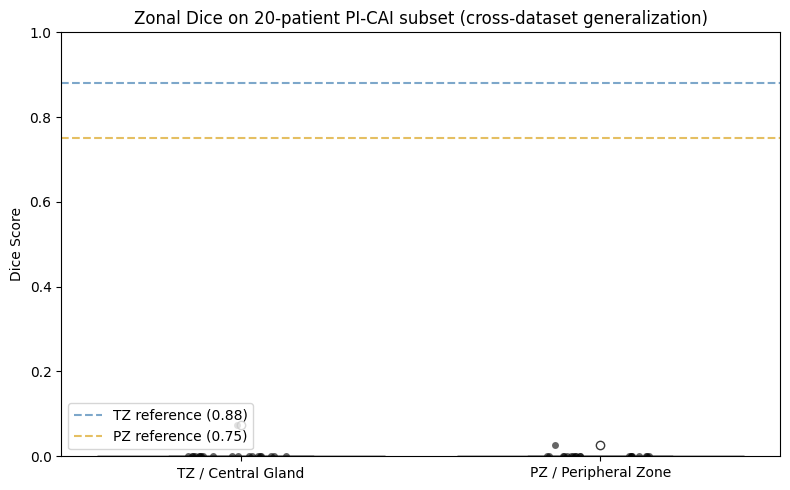

In [11]:
if len(dice_df) > 0:
    long_df = dice_df.melt(
        id_vars='case_id',
        value_vars=['dice_tz', 'dice_pz'],
        var_name='zone',
        value_name='dice',
    )
    long_df['zone'] = long_df['zone'].map({
        'dice_tz': 'TZ / Central Gland',
        'dice_pz': 'PZ / Peripheral Zone',
    })

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=long_df, x='zone', y='dice', ax=ax, palette='viridis')
    sns.stripplot(data=long_df, x='zone', y='dice', ax=ax, color='black', alpha=0.6, jitter=0.15)

    ax.axhline(0.88, ls='--', color='steelblue', alpha=0.7, label='TZ reference (0.88)')
    ax.axhline(0.75, ls='--', color='goldenrod', alpha=0.7, label='PZ reference (0.75)')
    ax.set_ylabel('Dice Score')
    ax.set_xlabel('')
    ax.set_ylim(0, 1)
    ax.set_title('Zonal Dice on 20-patient PI-CAI subset (cross-dataset generalization)')
    ax.legend(loc='lower left')
    plt.tight_layout()

    fig_path = FIGURES_DIR / 'anatomy_dice_boxplot.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Figure saved -> {fig_path}')
    plt.show()

---

## Step 3 — Outputs

After this notebook finishes successfully you should have:

- `output/anatomy_predictions/*_zonal_pred.nii.gz` — 20 NIfTI prediction masks (one per patient).
- `output/metrics/anatomy_dice_scores.csv` — per-case Dice for TZ and PZ plus voxel counts.
- `output/figures/anatomy_sample_prediction.png` — qualitative three-panel comparison (slide 6).
- `output/figures/anatomy_dice_boxplot.png` — Dice distribution vs prostate158 reference (slide 7).

**Next notebook:** `step4_lesion_inference.ipynb` — clinically-significant prostate-cancer (csPCa) detection with the PI-CAI U-Net baseline.